In [25]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import random

In [26]:
df = pd.read_csv(r"C:\Users\MATEJ\Documents\BDS SEMESTER 3\Network Analysis\Project\7267433\calls.csv") # Change accordingly, this is temp
G=nx.from_pandas_edgelist(df=df,source='caller',target='callee',edge_attr=['timestamp','duration'],create_using=nx.MultiDiGraph())
df

,timestamp,caller,callee,duration
0,184,300,301,121
1,3920,512,299,670
2,5623,301,300,504
3,9252,401,457,-1
4,15466,512,0,5
...,...,...,...,...
3595,2414934,706,401,78
3596,2415585,218,382,48
3597,2416059,561,631,13
3598,2416368,323,392,4


In [27]:
def get_largest_component(G):
    """
    Returns the largest connected component subgraph.
    Works for both directed and undirected graphs.
    """
    if G.is_directed():
        # Use weakly connected components for spread (ignores direction)
        largest_cc = max(nx.weakly_connected_components(G), key=len)
    else:
        largest_cc = max(nx.connected_components(G), key=len)
    return G.subgraph(largest_cc).copy()

In [28]:
def simulate_hoax(G, beta=0.3, gamma=0.05, steps=50):
    """
    Simulates hoax spread on graph G using an SIR-like model.
    beta = infection probability
    gamma = recovery probability
    steps = number of iterations
    """
    # Extract largest component
    G = get_largest_component(G)

    # Initialize states: 0=S, 1=I, 2=R
    state = {n: 0 for n in G.nodes()}

    # Infect a hub (highest degree node)
    hub = max(G.degree, key=lambda x: x[1])[0]
    state[hub] = 1

    # Track counts
    S, I, R = [], [], []

    for t in range(steps):
        new_state = state.copy()
        for node in G.nodes():
            if state[node] == 1:  # infected
                # Try to infect neighbors
                for neigh in G.neighbors(node):
                    if state[neigh] == 0 and random.random() < beta:
                        new_state[neigh] = 1
                # Recovery
                if random.random() < gamma:
                    new_state[node] = 2
        state = new_state

        # Count states
        S.append(sum(1 for v in state.values() if v == 0))
        I.append(sum(1 for v in state.values() if v == 1))
        R.append(sum(1 for v in state.values() if v == 2))

    return S, I, R

In [29]:
def simulate_carrier_model(G, beta_I=0.25, beta_C=0.45, gamma=0.05, steps=80, seeds=3):
    """
    States: 0=S, 1=I (infected), 2=C (carrier, not reinfected, still infectious)
    beta_I: infection prob from infected
    beta_C: infection prob from carriers
    gamma: I -> C transition prob
    """
    G = get_largest_component(G)

    # Seeds: pick high-degree nodes in different regions if possible
    deg_sorted = sorted(G.degree, key=lambda x: x[1], reverse=True)
    initial = [n for n, _ in deg_sorted[:seeds]]
    state = {n: 0 for n in G.nodes()}
    for n in initial:
        state[n] = 1

    S, I, C = [], [], []
    for t in range(steps):
        new_state = state.copy()
        for u in G.nodes():
            # choose infection probability based on state
            if state[u] == 1 or state[u] == 2:
                beta = beta_I if state[u] == 1 else beta_C
                # for directed graphs, use out-neighbors
                neighbors = G.successors(u) if G.is_directed() else G.neighbors(u)
                for v in neighbors:
                    if state[v] == 0 and random.random() < beta:
                        new_state[v] = 1
                # infected become carriers
                if state[u] == 1 and random.random() < gamma:
                    new_state[u] = 2
        state = new_state
        S.append(sum(1 for s in state.values() if s == 0))
        I.append(sum(1 for s in state.values() if s == 1))
        C.append(sum(1 for s in state.values() if s == 2))
    return S, I, C

In [30]:
def simulate_si_model(G, beta=0.2, steps=50, seed_count=1):
    G = get_largest_component(G)

    # Initialize states: 0 = Susceptible, 1 = Infected
    state = {n: 0 for n in G.nodes()}
    # Infect seed nodes (e.g., top-degree hubs)
    seeds = sorted(G.degree, key=lambda x: x[1], reverse=True)[:seed_count]
    for node, _ in seeds:
        state[node] = 1

    S, I = [], []

    for t in range(steps):
        new_state = state.copy()
        for node in G.nodes():
            if state[node] == 1:
                neighbors = G.successors(node) if G.is_directed() else G.neighbors(node)
                for neigh in neighbors:
                    if state[neigh] == 0 and random.random() < beta:
                        new_state[neigh] = 1
        state = new_state
        S.append(sum(1 for v in state.values() if v == 0))
        I.append(sum(1 for v in state.values() if v == 1))

    return S, I

In [31]:
def simulate_sis_model(G, beta=0.3, gamma=0.1, steps=60, seed_count=1):
    G = get_largest_component(G)

    # Initialize states: 0 = Susceptible, 1 = Infected
    state = {n: 0 for n in G.nodes()}
    seeds = sorted(G.degree, key=lambda x: x[1], reverse=True)[:seed_count]
    for node, _ in seeds:
        state[node] = 1

    S, I = [], []

    for t in range(steps):
        new_state = state.copy()
        for node in G.nodes():
            if state[node] == 1:
                neighbors = G.successors(node) if G.is_directed() else G.neighbors(node)
                for neigh in neighbors:
                    if state[neigh] == 0 and random.random() < beta:
                        new_state[neigh] = 1
                # Recovery
                if random.random() < gamma:
                    new_state[node] = 0
        state = new_state
        S.append(sum(1 for v in state.values() if v == 0))
        I.append(sum(1 for v in state.values() if v == 1))

    return S, I

In [53]:
def makeNiceFigure(G,beta,gamma,steps,beta_I,beta_C):
    plt.figure(figsize=(20,5))
    plt.subplot(1,4,1)
    S, I = simulate_si_model(G,beta=beta,steps=steps)
    plt.plot(S, label="Susceptible")
    plt.plot(I, label="Infected (hoax spreaders)")
    plt.xlabel("Time step")
    plt.ylabel("Number of nodes")
    plt.legend()
    plt.title("SI model")
    plt.grid(visible=True)

    plt.subplot(1,4,2)
    S, I = simulate_sis_model(G,beta=beta,gamma=gamma,steps=steps)
    plt.plot(S, label="Susceptible")
    plt.plot(I, label="Infected (hoax spreaders)")
    plt.xlabel("Time step")
    plt.ylabel("Number of nodes")
    plt.legend()
    plt.title("SIS model")
    plt.grid(visible=True)

    plt.subplot(1,4,3)
    S, I, C = simulate_carrier_model(G,beta_I=beta_I,beta_C=beta_C,gamma=gamma,steps=steps)
    plt.plot(S, label="Susceptible")
    plt.plot(I, label="Infected (hoax spreaders)")
    plt.plot(C, label="Carrier")
    plt.xlabel("Time step")
    plt.ylabel("Number of nodes")
    plt.legend()
    plt.title("SIC model")
    plt.grid(visible=True)

    plt.subplot(1,4,4)
    S, I, R = simulate_hoax(G, beta=beta, gamma=gamma, steps=steps)
    plt.plot(S, label="Susceptible")
    plt.plot(I, label="Infected (hoax spreaders)")
    plt.plot(R, label="Recovered")
    plt.xlabel("Time step")
    plt.ylabel("Number of nodes")
    plt.legend()
    plt.title("SIR model")
    plt.grid(visible=True)
    plt.show();

All models with 25% chance to spread


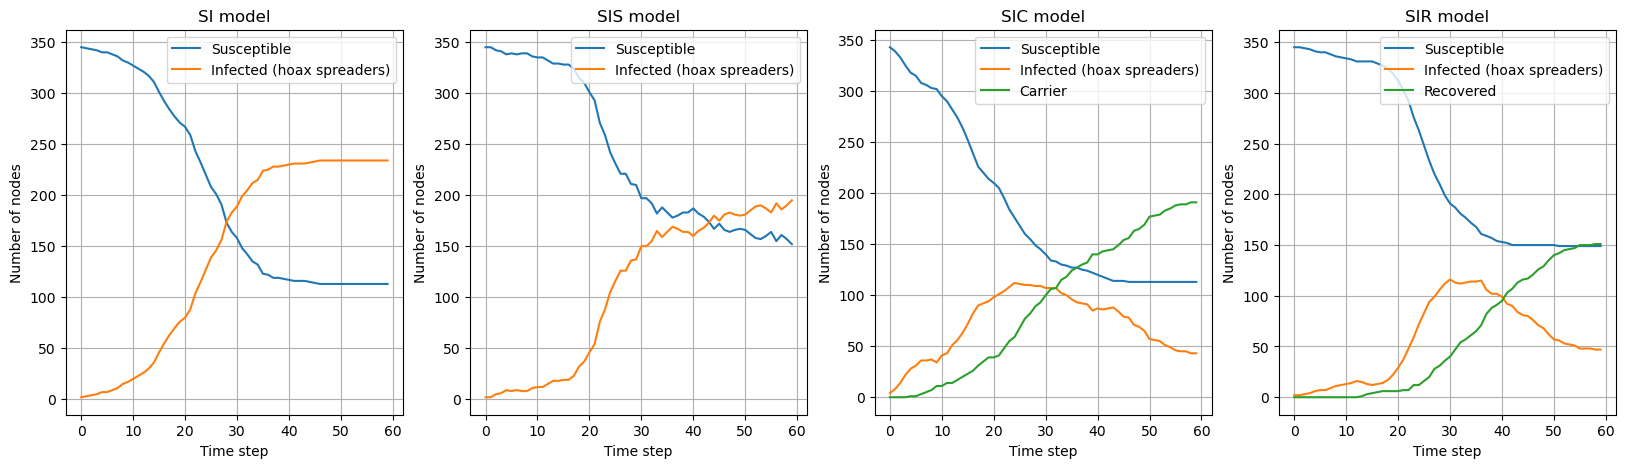

All models with 50% chance to spread


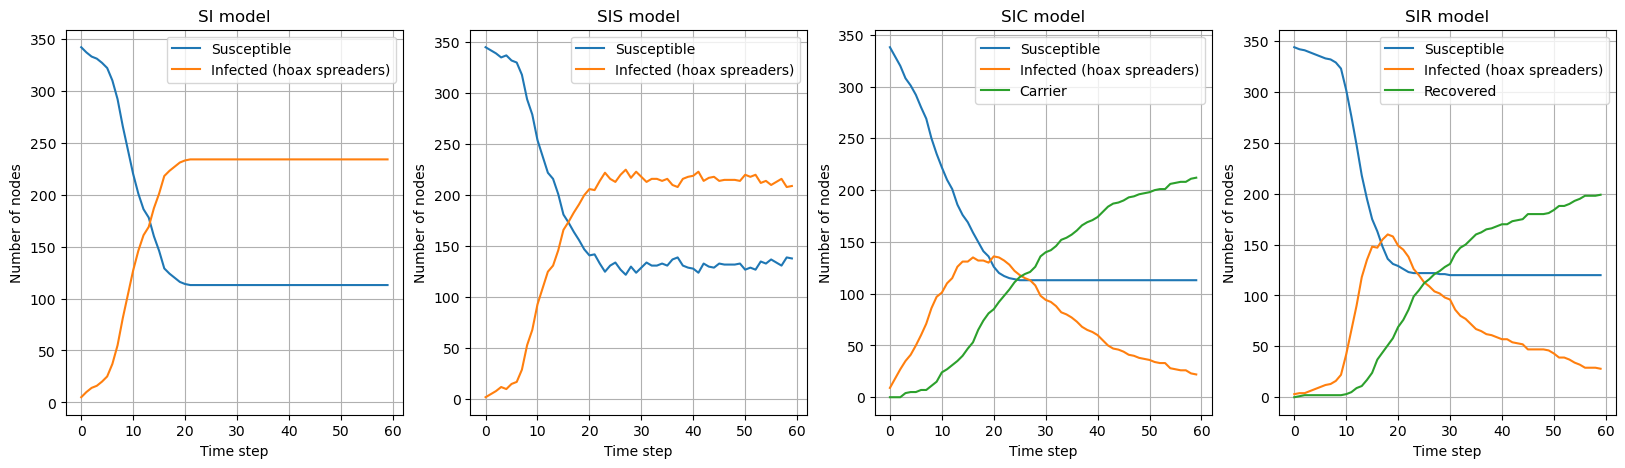

All models with 75% chance to spread


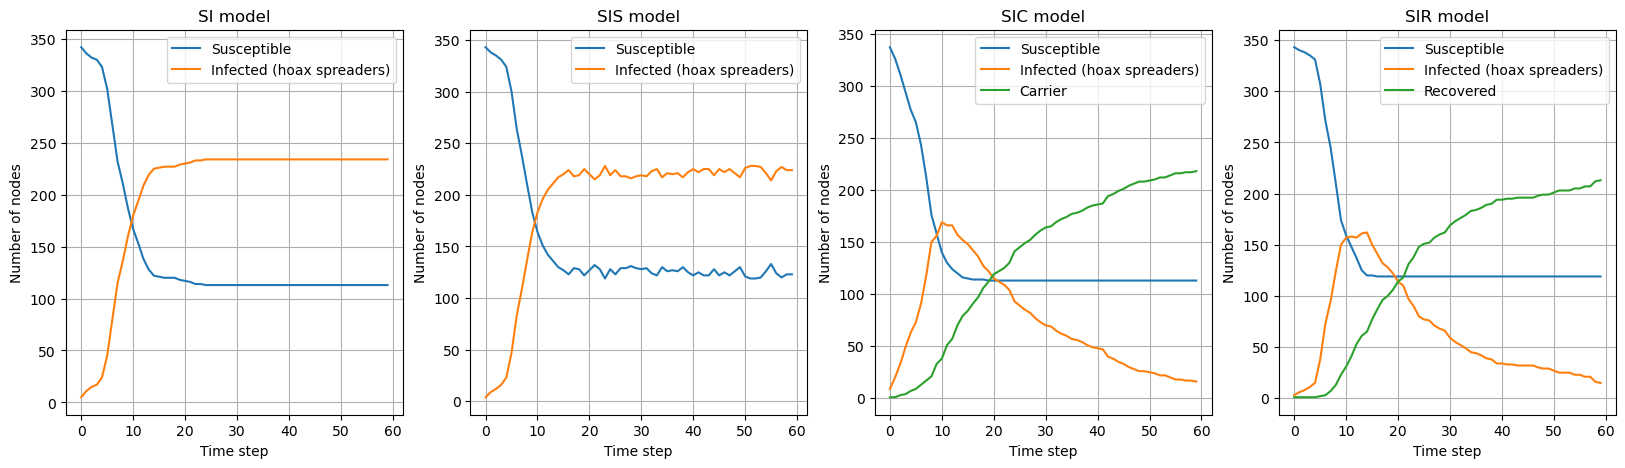

In [54]:
numSteps=60

print('All models with 25% chance to spread')
makeNiceFigure(G,beta=0.25,gamma=0.05,steps=numSteps,beta_I=0.25,beta_C=0.25)
print('All models with 50% chance to spread')
makeNiceFigure(G,beta=0.5,gamma=0.05,steps=numSteps,beta_I=0.5,beta_C=0.5)
print('All models with 75% chance to spread')
makeNiceFigure(G,beta=0.75,gamma=0.05,steps=numSteps,beta_I=0.75,beta_C=0.75)